In [1]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
from entropy import *

import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import goe
from tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as gamma_fun
from scipy.special import lambertw
from scipy.special import voigt_profile
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import splrep, splev
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import FancyArrowPatch

# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 1
modello = 'RP'


def base_dir(model, d, BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (f"" if model == 'PLRB' or model == 'RP' else  f"dim={d}/") + ( '' if model == 'RP' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/XXZ/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/RP/


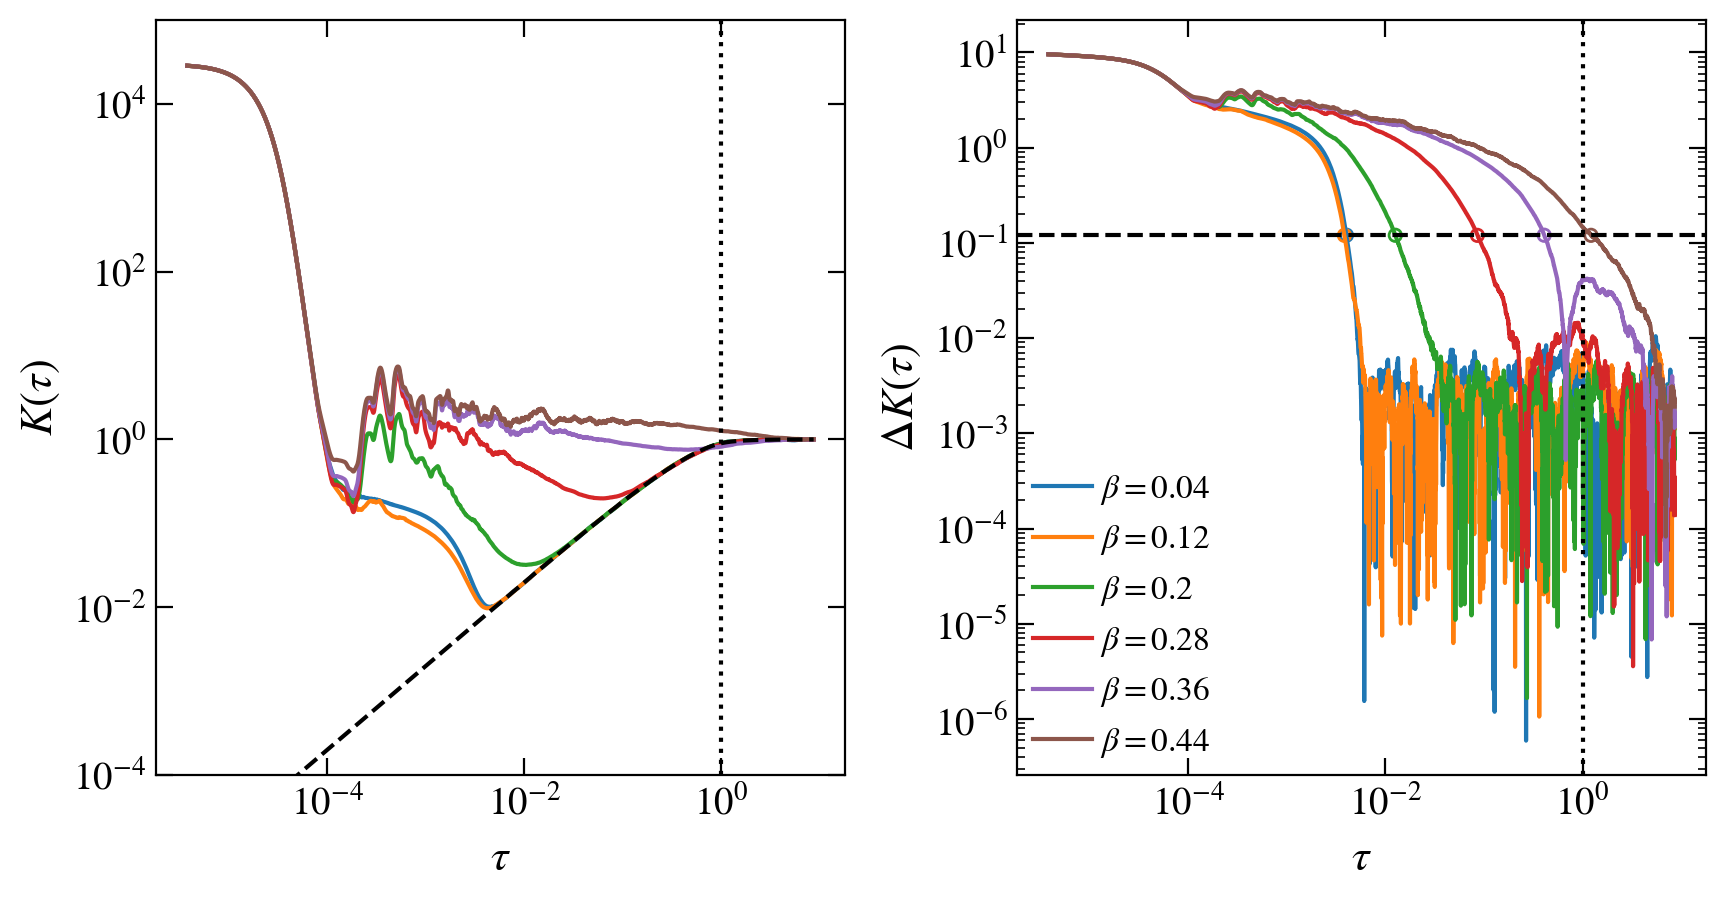

In [56]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

use_gap_or_weight = 0
BC = 0

prefix = '../results_fgr/disorder/OBC/' if BC else '../results_fgr_D/disorder/PBC/'
hz = 0
if not BC: use_gap_or_weight = 1

sizes = np.arange(12, 19, 2)


def lorenz(x, A, sig, G):
    return A / G / np.pi / ( (x / G)**2 + 1) * np.exp(-x**2 / (2*sig**2) ) /np.sqrt(2*np.pi*sig**2)
    # return A / np.sqrt(2*np.pi*sig**2) * np.exp(-x**2 / (2*sig**2))

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(10,5), dpi = 200, sharex=True)


L = 18

bucket = 100
folded = 0
raw = 0

running_mean = 1
eta = 0.5

epsilon=1.2e-1

betas = np.arange(0.04, 0.45, 0.08)

dim = binom(L, L//2)
for ii_a, wx in enumerate(betas):
    name = prefix + 'SpectralFormFactor/' + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            tHtyp = np.array(file.get('tH_typ'))[0] / ( 2 * np.pi )
            tH = np.array(file.get('tH'))[0] / ( 2 * np.pi )
            sigma = dim / tH
            # chi = 1/6 + np.sqrt(3) / 4 / np.pi if g <= 1 else 1/2*erf(1/np.sqrt(2))
            # tH = chi * L / np.sqrt(1 + (L+1) * L**(-g))
            times = np.array(file.get('times'))[0]
            sff = np.array(file.get("sff_eta"))[:,-1]
            # print(sff.shape)
            if raw:
                tH = tH * 2 * np.pi
                tHtyp = tHtyp * 2 * np.pi
                sff = np.array(file.get("sff_raw_folded"))[0]
                times = np.array(file.get('times_fold'))[0]# / tHtyp
            try:
                # # print(sff.shape)
                # if sff.shape == (1, 10000) or sff.shape == (1, 5000):
                #     sff = sff[0]
                #     times = times[0]
                if running_mean: 
                    sff = tools.remove_fluctuations(sff, bucket)
                    sff = sff[bucket // 2 : -bucket // 2]
                    times = times[bucket // 2 : -bucket // 2]
                    
                # times = times * L / 4
                axis[0].plot(times, sff)

                sff = np.abs( np.log10(sff / goe.spectral_form_factor(times / tHtyp if raw else times)) )
                pl = axis[1].plot(times, sff, label=r"$\beta=%g$"%wx)
                
                # sff = ( np.abs(sff - goe.spectral_form_factor(times)) )
                
                idx = (np.abs(sff - epsilon)).argmin()
                # for ii in range(20, len(sff)):
                #     if sff[ii-3] - sff[ii-2] > 0 and sff[ii-2] - sff[ii-1]:
                #         if sff[ii] - sff[ii-1] > 0 and sff[ii+1] - sff[ii]:
                #             if sff[ii+3] - sff[ii+2] > 0 and sff[ii+2] - sff[ii+1]:
                #                 idx = ii
                #                 break;  
                
                
                # pl = axis[1].plot(times, sff, label=r"$\beta=%g$"%wx)
                axis[1].scatter(times[idx], sff[idx], color=pl[0].get_color(), facecolor='None', s=20)
            except TypeError:
                print("Old file", name)
    else:
        print(name)
axis[0].plot(times, goe.spectral_form_factor(times / tHtyp  if raw else times), ls='--', c='k')
if raw:
    axis[0].plot(times, dim * np.exp(-sigma**2 * times**2 / 42), ls='-.', c='gray')
axis[1].axhline(y=epsilon, ls='--', c='k')
# axis[0].axhline(y=dim, ls=':', c='red')

axis[0].axvline(x=1, ls=':', c='k')
axis[1].axvline(x=1, ls=':', c='k')
fig_help.set_plot_elements(axis[0], ylabel=r"$K(\tau)$", xlabel=r"$\tau$", font_size=14, set_legend=False, xscale='log', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\Delta K(\tau)$", xlabel=r"$\tau$", font_size=14, set_legend=False, xscale='log', yscale='log')
fig_help.set_legend(axis[1], loc = 'lower left', fontsize=12, ncol=1)

axis[0].set_ylim(1e-4, 1e5)
# axis[0].set_xlim(1e-1, 10)
# fig_help.set_plot_elements(axis[1], ylabel=r"$\left\langle\bar{S}_A^{\ell}\right\rangle$", xlabel=rescale_func_names[iabc], font_size=14, set_legend=False)


fig.subplots_adjust(wspace = 0.25, hspace=0.2)

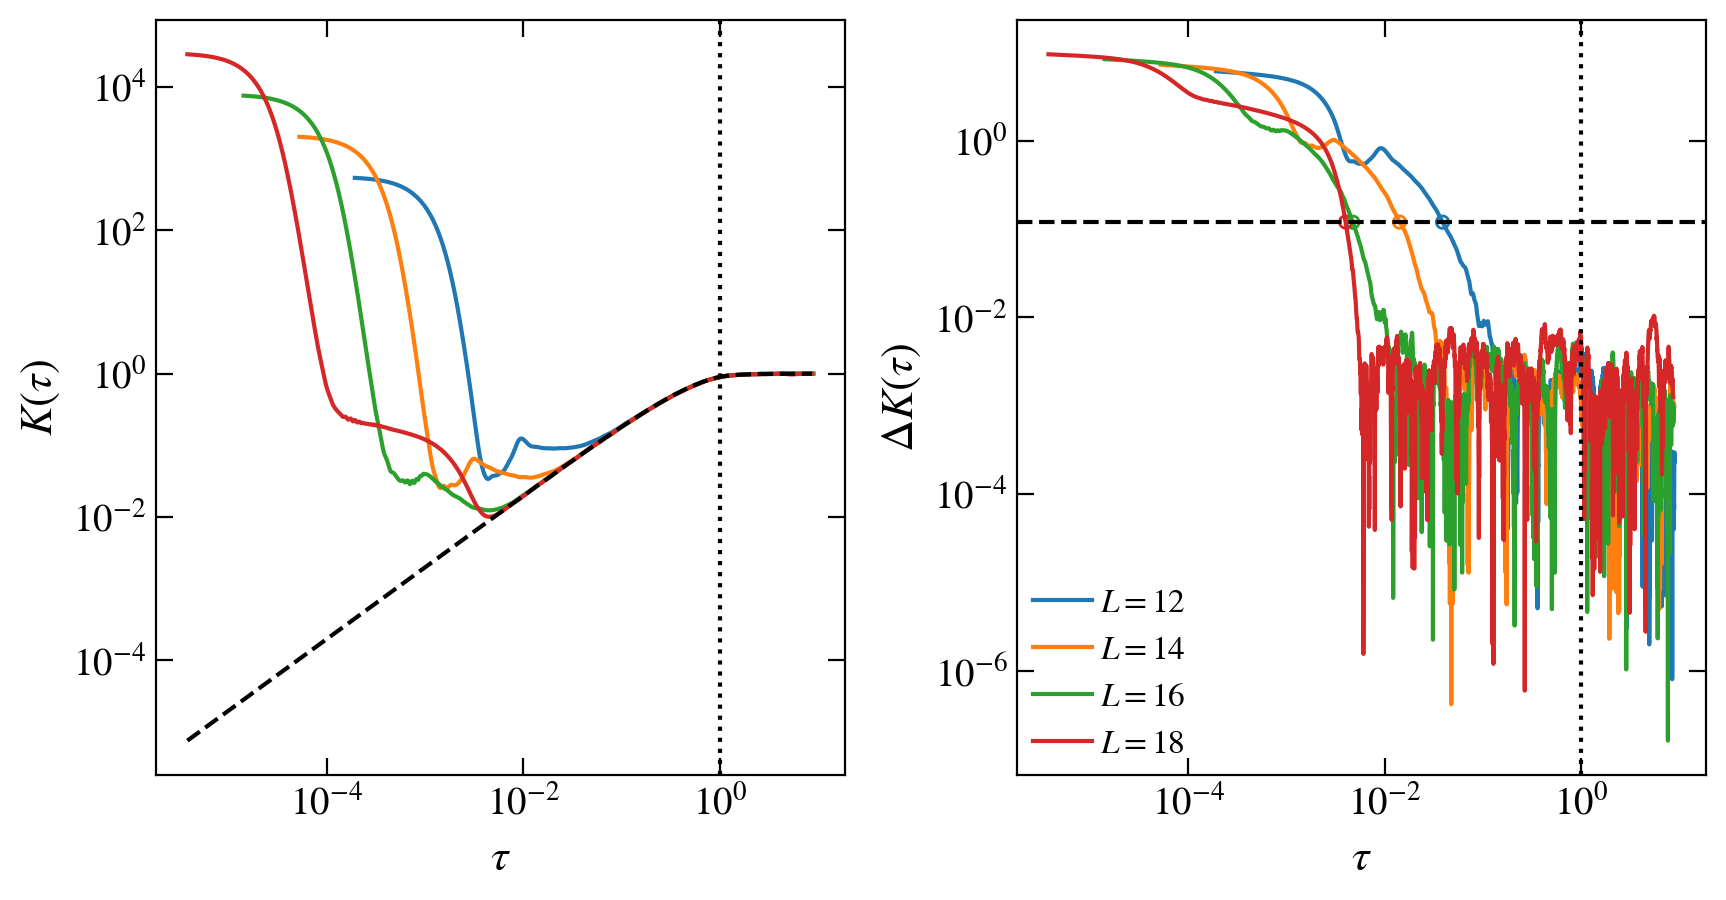

In [6]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

use_gap_or_weight = 0
BC = 0

prefix = '../results_fgr_D/disorder/OBC/' if BC else '../results_fgr_D/disorder/PBC/'
hz = 0
if not BC: use_gap_or_weight = 1

sizes = np.arange(12, 19, 2)


def lorenz(x, A, sig, G):
    return A / G / np.pi / ( (x / G)**2 + 1) * np.exp(-x**2 / (2*sig**2) ) /np.sqrt(2*np.pi*sig**2)
    # return A / np.sqrt(2*np.pi*sig**2) * np.exp(-x**2 / (2*sig**2))

norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

fig, axis = plt.subplots( nrows=1, ncols=2, figsize=(10,5), dpi = 200, sharex=True)


L = 18

bucket = 100
folded = 0
raw = 0

running_mean = 1
eta = 0.5

epsilon = 0.12

betas = np.arange(0.04, 0.31, 0.08)

wx = 0.04

for ii_a, L in enumerate(sizes):
    name = prefix + 'SpectralFormFactor/' + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
    if exists(name):
        with h5py.File(name, "r") as file:
            tHtyp = np.array(file.get('tH_typ'))[0] / ( 2 * np.pi )
            tH = np.array(file.get('tH'))[0] / ( 2 * np.pi )
            # chi = 1/6 + np.sqrt(3) / 4 / np.pi if g <= 1 else 1/2*erf(1/np.sqrt(2))
            # tH = chi * L / np.sqrt(1 + (L+1) * L**(-g))
            times = np.array(file.get('times'))[0]
            sff = np.array(file.get("sff_eta"))[:,-1]
            # print(sff.shape)
            if raw:
                tH = tH * 2 * np.pi
                tHtyp = tHtyp * 2 * np.pi
                sff = np.array(file.get("sff_raw"))
                times = np.array(file.get('times_fold'))[0] / tHtyp
            try:
                # # print(sff.shape)
                # if sff.shape == (1, 10000) or sff.shape == (1, 5000):
                #     sff = sff[0]
                #     times = times[0]
                if running_mean: 
                    sff = tools.remove_fluctuations(sff, bucket)
                    sff = sff[bucket // 2 : -bucket // 2]
                    times = times[bucket // 2 : -bucket // 2]
                    
                # times = times * L / 4
                axis[0].plot(times, sff)

                sff = np.abs( np.log10(sff / goe.spectral_form_factor(times)) )
                pl = axis[1].plot(times, sff, label=r"$L=%g$"%L)
                
                # sff = ( np.abs(sff - goe.spectral_form_factor(times)) )
                
                idx = (np.abs(sff - epsilon)).argmin()
                # for ii in range(20, len(sff)):
                #     if sff[ii-3] - sff[ii-2] > 0 and sff[ii-2] - sff[ii-1]:
                #         if sff[ii] - sff[ii-1] > 0 and sff[ii+1] - sff[ii]:
                #             if sff[ii+3] - sff[ii+2] > 0 and sff[ii+2] - sff[ii+1]:
                #                 idx = ii
                #                 break;  
                
                
                # pl = axis[1].plot(times, sff, label=r"$\beta=%g$"%wx)
                axis[1].scatter(times[idx], sff[idx], color=pl[0].get_color(), facecolor='None', s=20)
            except TypeError:
                print("Old file", name)
    else:
        print(name)
axis[0].plot(times, goe.spectral_form_factor(times), ls='--', c='k')
axis[1].axhline(y=epsilon, ls='--', c='k')

axis[0].axvline(x=1, ls=':', c='k')
axis[1].axvline(x=1, ls=':', c='k')
fig_help.set_plot_elements(axis[0], ylabel=r"$K(\tau)$", xlabel=r"$\tau$", font_size=14, set_legend=False, xscale='log', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\Delta K(\tau)$", xlabel=r"$\tau$", font_size=14, set_legend=False, xscale='log', yscale='log')
fig_help.set_legend(axis[1], loc = 'lower left', fontsize=12, ncol=1)

# axis[0].set_ylim(1e-1, 10)
# axis[0].set_xlim(1e-1, 10)
# fig_help.set_plot_elements(axis[1], ylabel=r"$\left\langle\bar{S}_A^{\ell}\right\rangle$", xlabel=rescale_func_names[iabc], font_size=14, set_legend=False)


fig.subplots_adjust(wspace = 0.25, hspace=0.2)

In [ ]:
name=gec
fun=30
dx=0.1
arr_end=50
arr_step=49

y=1

delta=0.55 #-0.48
J2=0.0

yvals=(1)	#0.5 0.75 1.5 2.0)
r=25

random_num=$RANDOM
# echo $L $dx $fun 1 $random_num $id $y $grain_size $conf_disorder $scaled_disorder
L=8;  sbatch --job-name="${name}_L=${L}" --output=logs/${name}_log-%A-%a.out --error=errors/${name}_log-%A-%a.out --cpus-per-task=8 --mem-per-cpu=2000 --time=12:00:00 --array=0-${arr_end}%${arr_step} runner_disorder.sh 8 $dx $fun 8 $random_num $id $delta $J2
L=10; sbatch --job-name="${name}_L=${L}" --output=logs/${name}_log-%A-%a.out --error=errors/${name}_log-%A-%a.out --cpus-per-task=8 --mem-per-cpu=2000 --time=12:00:00 --array=0-${arr_end}%${arr_step} runner_disorder.sh 10 $dx $fun 8 $random_num $id $delta $J2
L=12; sbatch --job-name="${name}_L=${L}" --output=logs/${name}_log-%A-%a.out --error=errors/${name}_log-%A-%a.out --cpus-per-task=8 --mem-per-cpu=2000 --time=12:00:00 --array=0-${arr_end}%${arr_step} runner_disorder.sh 12 $dx $fun 8 $random_num $id $delta $J2
L=14; sbatch --job-name="${name}_L=${L}" --output=logs/${name}_log-%A-%a.out --error=errors/${name}_log-%A-%a.out --cpus-per-task=8 --mem-per-cpu=2000 --time=24:00:00 --array=0-${arr_end}%${arr_step} runner_disorder.sh 14 $dx $fun 8 $random_num $id $delta $J2
L=16; sbatch --job-name="${name}_L=${L}" --output=logs/${name}_log-%A-%a.out --error=errors/${name}_log-%A-%a.out --cpus-per-task=16 --mem-per-cpu=2000 --time=24:00:00 --array=0-${arr_end}%${arr_step} runner_disorder.sh 16 $dx $fun 16 $random_num $id $delta $J2
L=18; sbatch --job-name="${name}_L=${L}" --output=logs/${name}_log-%A-%a.out --error=errors/${name}_log-%A-%a.out --cpus-per-task=16 --mem-per-cpu=2000 --time=48:00:00 --array=0-${arr_end}%${arr_step} runner_disorder.sh 18 $dx $fun 16 $random_num $id $delta $J2
L=20; sbatch --job-name="${name}_L=${L}" --output=logs/${name}_log-%A-%a.out --error=errors/${name}_log-%A-%a.out --cpus-per-task=16 --mem-per-cpu=2000 --time=48:00:00 --array=0-${arr_end}%${arr_step} runner_disorder.sh 20 $dx $fun 16 $random_num $id $delta $J2
# L=22; sbatch --job-name="${name}_L=${L}" --output=logs/${name}_log-%A-%a.out --error=errors/${name}_log-%A-%a.out --cpus-per-task=16 --mem-per-cpu=2000 --time=48:00:00 --array=0-${arr_end}%${arr_step} runner_disorder.sh 22 $dx $fun 16 $random_num $id $delta $J2
# sleep 1

../results_fgr_D/disorder/PBC/SpectralFormFactor/_L=14,J1=1,J2=0,d1=0.55,d2=0,hz=0,w=0.5,pb=0.hdf5
../results_fgr_D/disorder/PBC/SpectralFormFactor/_L=16,J1=1,J2=0,d1=0.55,d2=0,hz=0,w=0.26,pb=0.hdf5
../results_fgr_D/disorder/PBC/SpectralFormFactor/_L=16,J1=1,J2=0,d1=0.55,d2=0,hz=0,w=0.54,pb=0.hdf5


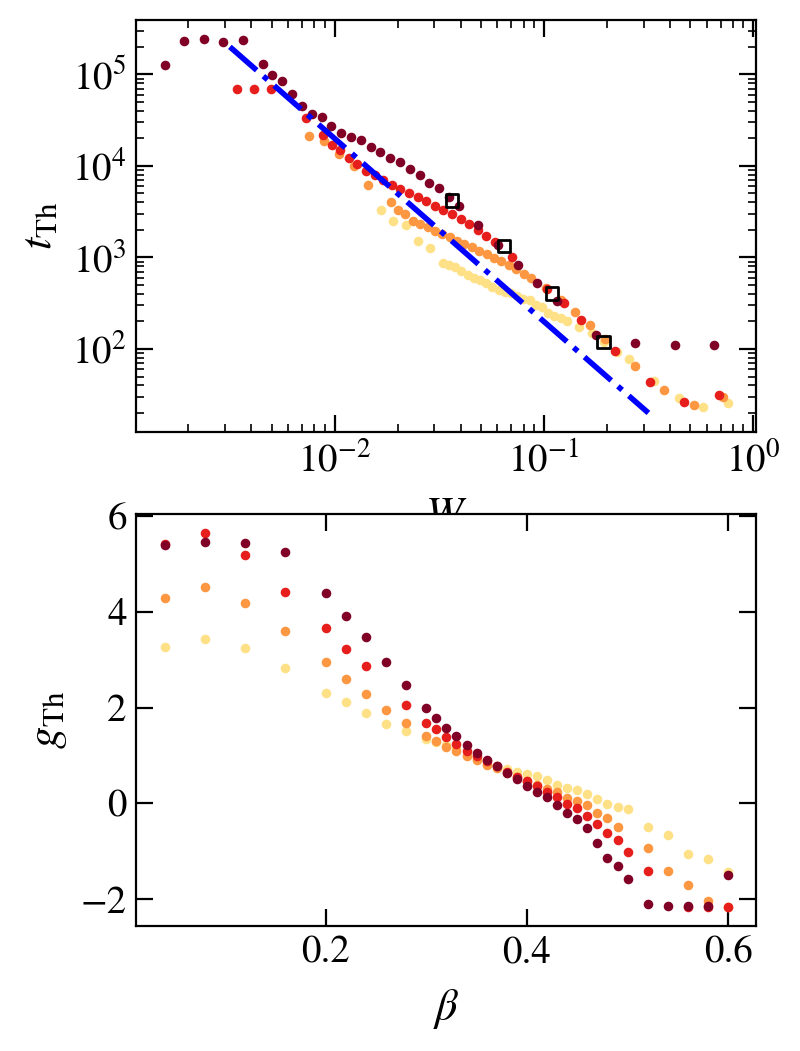

In [5]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

use_gap_or_weight = 0
BC = 0

prefix = '../results_fgr_D/disorder/OBC/' if BC else '../results_fgr_D/disorder/PBC/'
hz = 0
if not BC: use_gap_or_weight = 1

sizes = np.arange(12, 19, 2)

fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,6), dpi = 200)


L = 18

bucket = 100
folded = 0
raw = 0

running_mean = 1
eta = 0.5

epsilon = 0.12

betas = np.sort( np.array([*np.arange(0.04, 0.61, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )

folder = f'./thouless time/'
os.makedirs(folder, exist_ok=True)

sizes = np.arange(12, 19, 2)
norm = matplotlib.colors.Normalize(
    vmin=min(sizes),
    vmax=max(sizes))
# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)
s_m_L = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m_L.set_array([])


agp_max_tau = np.zeros(sizes.shape)
agp_max_pos = np.zeros(sizes.shape)

for iiL, L in enumerate(sizes):
    dim = binom(L, L//2)
    
    t_Th   = np.zeros((betas.size))
    tH     = np.zeros((betas.size))
    tH_typ = np.zeros((betas.size))
    ratio  = np.zeros((betas.size))
    name_out = folder + f'_L={L}.hdf5'
    for ii_g, wx in enumerate(betas):
        name = prefix + 'SpectralFormFactor/' + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        
        if exists(name):
            with h5py.File(name, "r") as file:
                tH[ii_g]     = np.array(file.get('tH'))[0]
                tH_typ[ii_g] = np.array(file.get('tH_typ'))[0]
                ratio[ii_g]  = np.array(file.get('r_500'))[0]
                
                times = np.array(file.get('times'))[0]
                sff = np.array(file.get("sff_eta"))[:,-2]
                # print(sff.shape)
                if raw:
                    tH = tH * 2 * np.pi
                    tHtyp = tHtyp * 2 * np.pi
                    sff = np.array(file.get("sff_raw"))
                    times = np.array(file.get('times_fold'))[0] / tHtyp
                if raw:
                    tH_analytical = tH_analytical * 2 * np.pi
                    sff = np.array(file.get("sff_raw"))
                    times = np.array(file.get('times_fold')) / tH_analytical
                try:
                    sff = tools.remove_fluctuations(sff, bucket)
                    sff = sff[bucket // 2 : -bucket // 2]
                    times = times[bucket // 2 : -bucket // 2]
                    
                    sff = np.abs( np.log10(sff / goe.spectral_form_factor(times)) )
                    idx = (np.abs(sff - epsilon)).argmin()
                    # sff = ( (sff - goe.spectral_form_factor(times)) )
                    # idx = (np.abs(sff)).argmin()
                    
                    
                    t_Th[ii_g] = times[idx]
                except TypeError:
                    t_Th[ii_g] = np.nan
                    print("Old file", name)
        else:
            # t_Th[ii_alfa] = t_Th[ii_alfa-1]
            # tH[ii_alfa] = tH[ii_alfa-1]
            # tH_typ[ii_alfa] = tH_typ[ii_alfa-1]
            print(name)
    
    axis[0].scatter(dim**(-betas), t_Th * tH, color=s_m_L.to_rgba(L), s=6)
    axis[1].scatter(betas, -np.log(t_Th), color=s_m_L.to_rgba(L), s=6)
    dim = int( binom(L, L//2) )

    col = s_m.to_rgba(L)
    wx_vals = betas
    gap_ratio = np.zeros(wx_vals.shape);    gap_ratio.fill(np.nan);
    agp = np.zeros(wx_vals.shape);    agp.fill(np.nan);
    realis = np.zeros(wx_vals.shape);    realis.fill(np.nan);
    
    sigma_num = np.zeros(wx_vals.shape)
    for iiw, wx in enumerate(wx_vals):
        
        name = prefix + 'Spectrals_SzSz/' + info_dis(L=L, J1=J, delta1=0.55, w=wx, hz=hz) + '.hdf5'
        if exists(name):
            with h5py.File(name, "r") as file:
                wH = np.array(file.get('wH'))[-2]
                Ex = np.array(file.get('average energies'))
                Eav = np.mean(Ex)
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - Eav))
                
                num = dim//2
                # num = min([500, dim//10])
                if L < 20: gap_ratio[iiw] = np.mean(np.array(file.get('gap_ratios'))[idx - num//2 : idx + num//2]) if use_gap_or_weight else 1-np.mean( np.array(file.get('weight_ratios'))[idx - num//2 : idx + num//2])
                else:      gap_ratio[iiw] = np.mean(np.array(file.get('gap_ratios'))) if use_gap_or_weight else 1-np.mean( np.array(file.get('weight_ratios')))
                # gap_ratio[iiw] = np.mean(np.array(file.get('gap_ratios'))) if use_gap_or_weight else 1-np.mean( np.array(file.get('weight_ratios')))
                # agp[iiL] = np.array(file.get('SUSC_R'))[-2] * wH
                agp[iiw] = np.array(file.get('TYP_SUSC_R'))[-2] * wH# if L < 20 else np.array(file.get('TYP_SUSC_R'))[-2] * wH
                # agp[iiw] = np.array(file.get('SUSC_R'))[-2] * wH
                # agp[iiw] = np.array(file.get('susc'))[0]
                
                realis[iiw] = np.array(file.get('realisations'))
                sigma_num[iiw] = np.mean( np.array(file.get('stddev')) )
                # sigma_num[iiw] = np.mean( np.array(file.get('bandwidth')) )
        else:
            print(name)
    
    gap_ratio = gap_ratio[~np.isinf(agp)]
    wx_vals = wx_vals[~np.isinf(agp)]
    agp = agp[~np.isinf(agp)]
    
    xx = wx_vals[wx_vals > 0.05]
    
    sigma = sigma_num[wx_vals > 0.05]#np.sqrt( (2 + delta**2 )/4 + dim**(-2*xx) / 3) / 2 * np.sqrt(L)
    # xx = xx + np.log(1/0.3413 * sigma) / (2*np.log( binom(L, L//2) ))
    yy = agp[wx_vals > 0.05]
    yy2 = (t_Th * tH)[wx_vals > 0.05]
    
    indices = np.arange( max([np.argmax(yy) - 5, 0]), min([np.argmax(yy) + 7,xx.size]), 1)
    x = np.linspace(xx[indices][0], xx[indices][-1], 1000)
    f = splrep(xx[indices], yy[indices], k=5, s=0)
    yy = splev(x, f)
    idx = np.argmax(yy)
    agp_max_pos[iiL] = dim**(-x[idx])
    
    f = splrep(xx[indices], yy2[indices], k=5, s=0)
    yy = splev(x, f)
    agp_max_tau[iiL] = yy[idx]
    
    hf = h5py.File(name_out, 'w')
    hf.create_dataset('interaction',             betas.shape,      data = betas)
    hf.create_dataset('thouless time',           t_Th.shape,       data = t_Th)
    hf.create_dataset('heisenberg time',         tH.shape,         data = tH)
    hf.create_dataset('typical heisenberg time', tH_typ.shape,     data = tH_typ)
    hf.create_dataset('gap ratio',               ratio.shape,      data = ratio)
    hf['agp_max_pos'] = dim**(-x[idx])
    hf['agp_max_tau'] = yy[idx]
    hf.close()
    
axis[0].scatter(agp_max_pos, agp_max_tau, marker='s', s=20, color='k', facecolor='None')

z = np.logspace(-2.5,-0.5, 100)
axis[0].plot(z, 2 / z**2, ls='-.', color='blue', lw=2)
fig_help.set_plot_elements(axis[0], ylabel=r"$t_{\rm Th}$", xlabel=r"$W$", font_size=14, set_legend=False, xscale='log', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$g_{\rm Th}$", xlabel=r"$\beta$", font_size=14, set_legend=False, xscale='linear', yscale='linear')

(35,)
(35,)
(35,)
(35,)


(12.0, 300000.0)

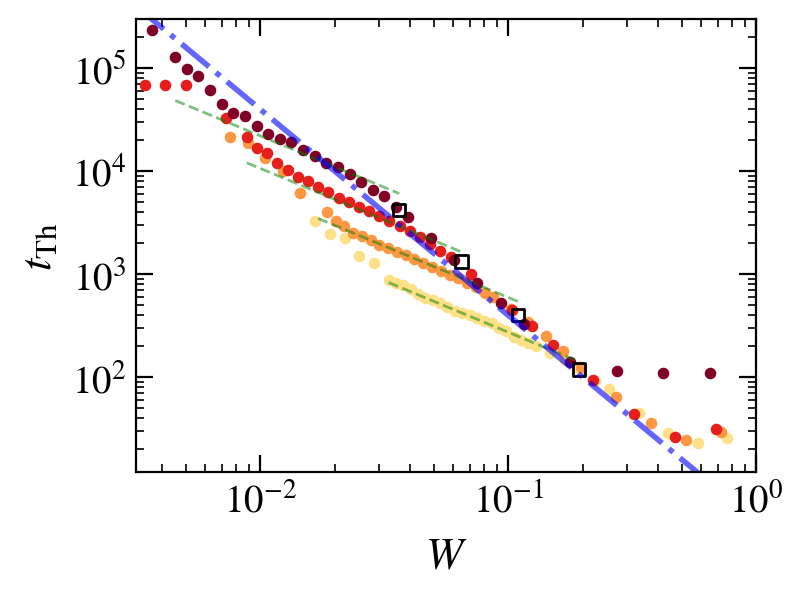

In [ ]:
colors_ls_cyc = itertools.cycle(colors_ls)
colors_ls_cyc2 = itertools.cycle(colors_ls)

L = 20
w = 2
J = 1
g=0.2
op=0

use_gap_or_weight = 0
BC = 0

prefix = '../results_fgr/disorder/OBC/' if BC else '../results_fgr/disorder/PBC/'
hz = 0
if not BC: use_gap_or_weight = 1

sizes = np.arange(12, 19, 2)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,3), dpi = 200)


L = 18

bucket = 100
folded = 0
raw = 0

running_mean = 1
eta = 0.5

epsilon = 0.12

betas = np.sort( np.array([*np.arange(0.04, 0.61, 0.04), *np.arange(0.22, 0.61, 0.04), *np.arange(0.31, 0.51, 0.02)]) )

folder = f'./thouless time/'
os.makedirs(folder, exist_ok=True)

sizes = np.arange(12, 19, 2)
norm = matplotlib.colors.Normalize(
    vmin=min(sizes),
    vmax=max(sizes))
# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)
s_m_L = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m_L.set_array([])


agp_max_tau = np.zeros(sizes.shape)
agp_max_pos = np.zeros(sizes.shape)


for iiL, L in enumerate(sizes):
    dim = binom(L, L//2)
    col = s_m_L.to_rgba(L)
    t_Th   = np.zeros((betas.size))
    tH     = np.zeros((betas.size))
    tH_typ = np.zeros((betas.size))
    ratio  = np.zeros((betas.size))
    name_out = folder + f'_L={L}.hdf5'
    if exists(name_out):
        with h5py.File(name_out, "r") as file:
            alfa_vals  = np.array(file.get('interaction'))
            tH         = np.array(file.get('heisenberg time'))
            tH_typ     = np.array(file.get('typical heisenberg time'))
            t_Th       = np.array(file.get('thouless time'))
            ratio      = np.array(file.get('gap ratio'))
            agp_max_pos[iiL] = np.array(file.get('agp_max_pos'))
            agp_max_tau[iiL] = np.array(file.get('agp_max_tau'))
            print(ratio.shape)
    else:
        print(name_out)
    
    axis.scatter(dim**(-betas), t_Th * tH, color=col, s=10)
    # axis[1].scatter(betas, -np.log(t_Th), color=s_m_L.to_rgba(L), s=10)

    x = agp_max_pos[iiL] / 2
    idx = np.argmin(np.abs(dim**(-betas) - x))
    z = np.linspace(dim**(-0.5), agp_max_pos[iiL], 1000)
    axis.plot(z, (t_Th * tH)[idx] / (z/x), ls='--', color='green', lw=1, alpha=0.5)
    # axis.axvline(x=dim**(-0.5), ls=':', color=col)
axis.scatter(agp_max_pos, agp_max_tau, marker='s', s=20, color='k', facecolor='None')

z = np.logspace(-2.5,0, 100)

















axis.plot(z, 4 / z**2, ls='-.', color='blue', lw=2, alpha=0.6)

fig_help.set_plot_elements(axis, ylabel=r"$t_{\rm Th}$", xlabel=r"$W$", font_size=14, set_legend=False, xscale='log', yscale='log')

axis.set_xlim(10**(-2.5), 1)
axis.set_ylim(1.2e1, 3e5)

In [82]:
(2**16)**2 * 8/1e9

34.359738368